## Cell 1 — Install dependencies

In [1]:
!pip install ultralytics -q
import os
os.environ["WANDB_DISABLED"] = "true"   # disable wandb logging on Kaggle
!pip install ultralytics pillow tqdm matplotlib -q
import torch
print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.3 MB/s eta 0:00:00
PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4


## Cell 2 — Configuration  ← **Edit this cell**

In [2]:
import os

# ── PATHS ─────────────────────────────────────────────────────────────────────
DF2_ROOT  = "/kaggle/input/datasets/sasank93/vr-mini-project-1/VR_Mini_project_data"    # root folder of DeepFashion2 dataset
YOLO_ROOT = "/kaggle/working/deepfashion2_yolo"      # where converted dataset will be saved

# ── MODEL ─────────────────────────────────────────────────────────────────────
# Options: yolov8n.pt | yolov8s.pt | yolov8m.pt | yolov8l.pt | yolov8x.pt
# n=fastest/smallest, x=slowest/most accurate
BASE_MODEL = "yolov8n.pt"

# ── TRAINING HYPER-PARAMETERS ─────────────────────────────────────────────────
EPOCHS    = 15
IMGSZ     = 640
BATCH     = 16      # reduce to 8 or 4 if you get CUDA OOM
LR0       = 1e-3    # initial learning rate
LRF       = 1e-2    # final lr factor  (final_lr = LR0 * LRF)
PATIENCE  = 5      # early stopping patience
WORKERS   = 2
PROJECT   = "/kaggle/working/runs/deepfashion2"
RUN_NAME  = "yolov8n_df2"
DEVICE    = 0 if torch.cuda.is_available() else "cpu"
MAX_SAMPLES = 30000   # use ~30k for train, all val for proper evaluation

# ── INFERENCE THRESHOLDS ──────────────────────────────────────────────────────
CONF_THRESH    = 0.40
IOU_THRESH     = 0.45
MIN_AREA_FRAC  = 0.005   # boxes covering < 0.5% of image are discarded
MIN_ASPECT     = 0.15    # discard extreme sliver boxes
MAX_ASPECT     = 6.5

print("Config loaded ✓")
print(f"  DF2_ROOT  : {DF2_ROOT}")
print(f"  YOLO_ROOT : {YOLO_ROOT}")
print(f"  BASE_MODEL: {BASE_MODEL}")
print(f"  DEVICE    : {DEVICE}")

Config loaded ✓
  DF2_ROOT  : /kaggle/input/datasets/sasank93/vr-mini-project-1/VR_Mini_project_data
  YOLO_ROOT : /kaggle/working/deepfashion2_yolo
  BASE_MODEL: yolov8n.pt
  DEVICE    : 0


## Cell 3 — DeepFashion2 → YOLO format conversion

In [3]:
import json
import shutil
from pathlib import Path
from PIL import Image
from tqdm import tqdm

CATEGORY_NAMES = [
    "short_sleeve_top", "long_sleeve_top",
    "short_sleeve_outwear", "long_sleeve_outwear",
    "vest", "sling",
    "shorts", "trousers", "skirt",
    "short_sleeve_dress", "long_sleeve_dress",
    "vest_dress", "sling_dress",
]
# category_id in DF2 is 1-indexed → YOLO class is 0-indexed
CAT_TO_YOLO = {i+1: i for i in range(13)}


def convert_split(df2_split_dir, yolo_split_dir):
    img_src = Path(df2_split_dir) / "image"
    ann_src = Path(df2_split_dir) / "annos"

    img_dst = Path(yolo_split_dir) / "images"
    lbl_dst = Path(yolo_split_dir) / "labels"
    img_dst.mkdir(parents=True, exist_ok=True)
    lbl_dst.mkdir(parents=True, exist_ok=True)

    ann_files = sorted(ann_src.glob("*.json"))
    skipped = 0

    if "train" in str(df2_split_dir) and MAX_SAMPLES:
        ann_files = ann_files[:MAX_SAMPLES]

    for ann_file in tqdm(ann_files, desc=f"Converting {Path(df2_split_dir).name}"):
        with open(ann_file) as f:
            ann = json.load(f)

        img_name = ann_file.stem + ".jpg"
        img_path = img_src / img_name
        if not img_path.exists():
            skipped += 1
            continue

        with Image.open(img_path) as img:
            W, H = img.size

        lines = []
        for key, val in ann.items():
            if not key.startswith("item"):
                continue
            cat_id = val.get("category_id")
            bbox   = val.get("bounding_box")  # [x1, y1, x2, y2] absolute
            if cat_id is None or bbox is None:
                continue

            x1, y1, x2, y2 = bbox
            x1, x2 = max(0, x1), min(W, x2)
            y1, y2 = max(0, y1), min(H, y2)
            bw, bh = x2 - x1, y2 - y1
            if bw <= 0 or bh <= 0:
                continue

            cx = (x1 + bw / 2) / W
            cy = (y1 + bh / 2) / H
            nw = bw / W
            nh = bh / H

            cls = CAT_TO_YOLO[cat_id]
            lines.append(f"{cls} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}")

        if not lines:
            skipped += 1
            continue

        (lbl_dst / (ann_file.stem + ".txt")).write_text("\n".join(lines))
        shutil.copy2(img_path, img_dst / img_name)

    print(f"  Done — skipped {skipped} files")


# Run conversion for both splits
# Clear previously converted data to start fresh
for split in ["train", "val"]:
    split_path = Path(YOLO_ROOT) / split
    if split_path.exists():
        shutil.rmtree(split_path)
        print(f"Cleared: {split_path}")
convert_split(f"{DF2_ROOT}/train",      f"{YOLO_ROOT}/train")
convert_split(f"{DF2_ROOT}/validation", f"{YOLO_ROOT}/val")
print("\nConversion complete ✓")

Converting train: 100%|██████████| 30000/30000 [06:53<00:00, 72.56it/s]


  Done — skipped 0 files


Converting validation: 100%|██████████| 32153/32153 [07:46<00:00, 68.93it/s]

  Done — skipped 0 files

Conversion complete ✓


## Cell 4 — Write dataset YAML

In [4]:
YAML_PATH = f"{YOLO_ROOT}/deepfashion2.yaml"

yaml_content = f"""# DeepFashion2 YOLO dataset config
path: {os.path.abspath(YOLO_ROOT)}
train: train/images
val:   val/images

nc: 13
names:
  0: short_sleeve_top
  1: long_sleeve_top
  2: short_sleeve_outwear
  3: long_sleeve_outwear
  4: vest
  5: sling
  6: shorts
  7: trousers
  8: skirt
  9: short_sleeve_dress
  10: long_sleeve_dress
  11: vest_dress
  12: sling_dress
"""

Path(YAML_PATH).write_text(yaml_content)
print(f"YAML written to: {YAML_PATH}")
print(yaml_content)

YAML written to: /kaggle/working/deepfashion2_yolo/deepfashion2.yaml
# DeepFashion2 YOLO dataset config
path: /kaggle/working/deepfashion2_yolo
train: train/images
val:   val/images

nc: 13
names:
  0: short_sleeve_top
  1: long_sleeve_top
  2: short_sleeve_outwear
  3: long_sleeve_outwear
  4: vest
  5: sling
  6: shorts
  7: trousers
  8: skirt
  9: short_sleeve_dress
  10: long_sleeve_dress
  11: vest_dress
  12: sling_dress



## Cell 5 — Dataset sanity check

train   images: 30,000   labels: 30,000
val     images: 32,153   labels: 32,153

Sample images with bounding boxes:


/tmp/ipykernel_23/1550463078.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab20", 13)


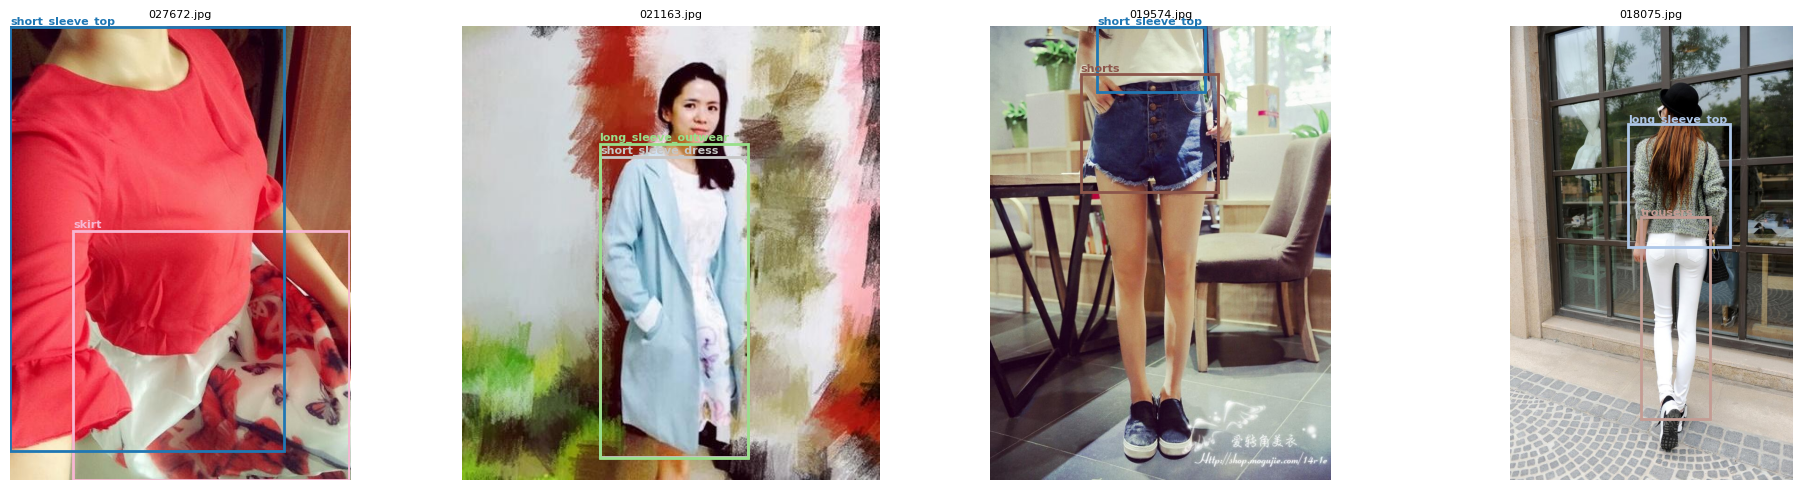

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import random
import numpy as np

def visualise_sample(yolo_root, split="train", n=4):
    img_dir = Path(yolo_root) / split / "images"
    lbl_dir = Path(yolo_root) / split / "labels"
    imgs = list(img_dir.glob("*.jpg"))
    sample = random.sample(imgs, min(n, len(imgs)))

    fig, axes = plt.subplots(1, len(sample), figsize=(5 * len(sample), 5))
    if len(sample) == 1:
        axes = [axes]

    colors = plt.cm.get_cmap("tab20", 13)

    for ax, img_path in zip(axes, sample):
        img = np.array(Image.open(img_path))
        H, W = img.shape[:2]
        ax.imshow(img)

        lbl_path = lbl_dir / (img_path.stem + ".txt")
        if lbl_path.exists():
            for line in lbl_path.read_text().strip().split("\n"):
                parts = line.split()
                cls, cx, cy, nw, nh = int(parts[0]), *map(float, parts[1:])
                x1 = (cx - nw/2) * W
                y1 = (cy - nh/2) * H
                bw, bh = nw * W, nh * H
                color = colors(cls)
                rect = patches.Rectangle((x1, y1), bw, bh,
                                          linewidth=2, edgecolor=color, facecolor="none")
                ax.add_patch(rect)
                ax.text(x1, y1 - 4, CATEGORY_NAMES[cls],
                        color=color, fontsize=8, fontweight="bold")

        ax.axis("off")
        ax.set_title(img_path.name, fontsize=8)

    plt.tight_layout()
    plt.show()

# Count samples
for split in ["train", "val"]:
    n_imgs = len(list((Path(YOLO_ROOT) / split / "images").glob("*.jpg")))
    n_lbls = len(list((Path(YOLO_ROOT) / split / "labels").glob("*.txt")))
    print(f"{split:6s}  images: {n_imgs:,}   labels: {n_lbls:,}")

print("\nSample images with bounding boxes:")
visualise_sample(YOLO_ROOT, split="train", n=4)

## Cell 6 — Fine-tune YOLOv8

In [6]:
from ultralytics import YOLO

model = YOLO(BASE_MODEL)   # downloads pretrained weights automatically

results = model.train(
    data     = YAML_PATH,
    epochs   = EPOCHS,
    imgsz    = IMGSZ,
    batch    = BATCH,
    lr0      = LR0,
    lrf      = LRF,
    patience = PATIENCE,
    workers  = WORKERS,
    project  = PROJECT,
    name     = RUN_NAME,
    device   = DEVICE,

    # Augmentation — tuned for fashion images
    hsv_h    = 0.015,   # hue shift
    hsv_s    = 0.4,     # saturation
    hsv_v    = 0.4,     # brightness
    fliplr   = 0.5,     # horizontal flip
    mosaic   = 1.0,
    mixup    = 0.1,

    save     = True,
    plots    = True,
)

BEST_WEIGHTS = f"{results.save_dir}/weights/best.pt"
print(f"\nTraining complete ✓")
print(f"Best weights: {BEST_WEIGHTS}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/deepfashion2_yolo/deepfashion2.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_

## Cell 7 — Training curves

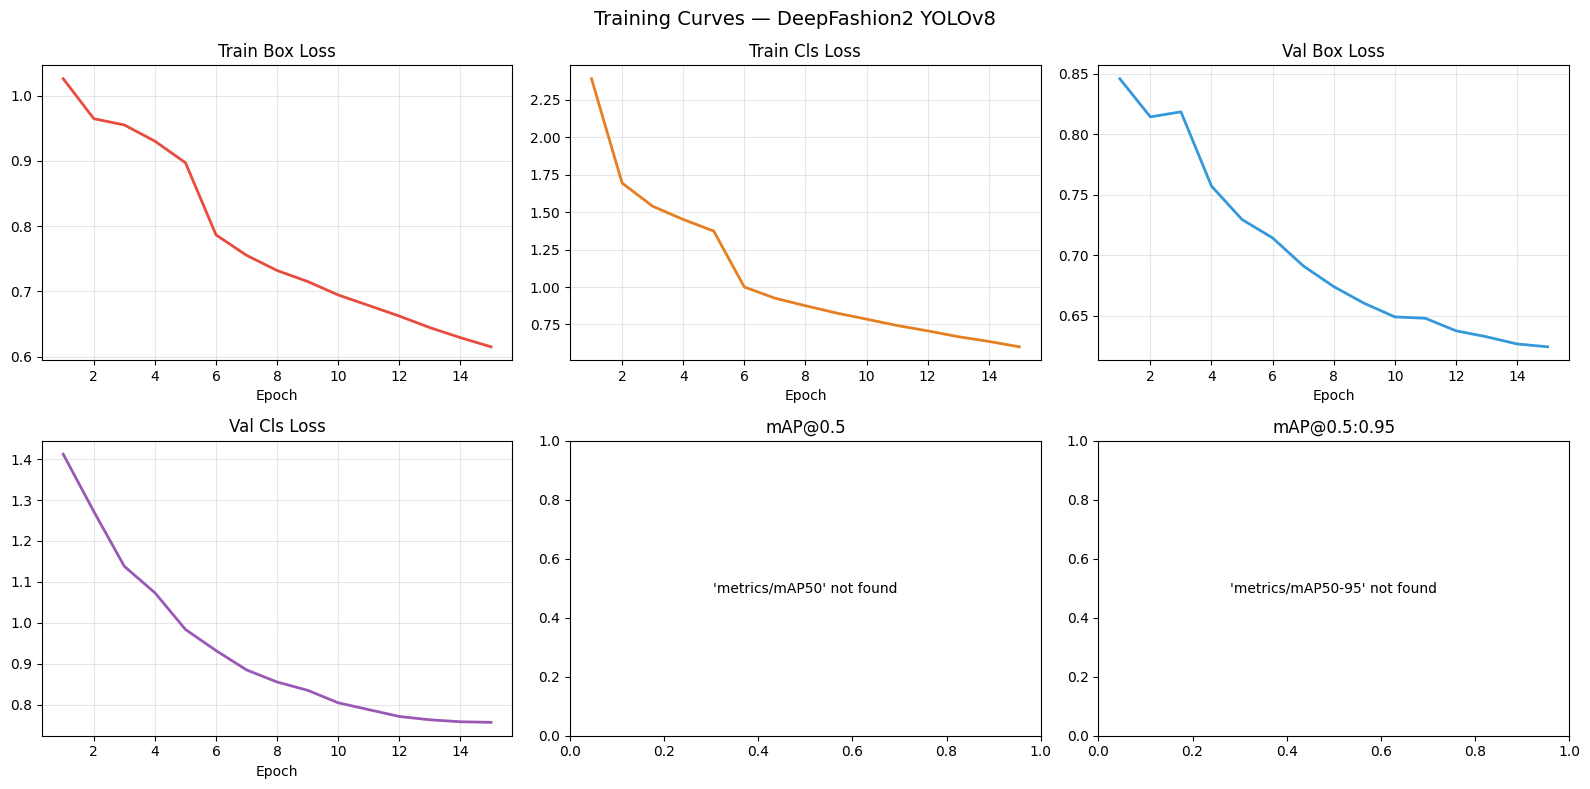

Saved: training_curves.png


In [7]:
import pandas as pd

csv_path = f"{results.save_dir}/results.csv"
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Training Curves — DeepFashion2 YOLOv8", fontsize=14)

metrics = [
    ("train/box_loss",  "Train Box Loss",  "#e74c3c"),
    ("train/cls_loss",  "Train Cls Loss",  "#e67e22"),
    ("val/box_loss",    "Val Box Loss",    "#3498db"),
    ("val/cls_loss",    "Val Cls Loss",    "#9b59b6"),
    ("metrics/mAP50",   "mAP@0.5",         "#2ecc71"),
    ("metrics/mAP50-95","mAP@0.5:0.95",   "#1abc9c"),
]

for ax, (col, title, color) in zip(axes.flat, metrics):
    if col in df.columns:
        ax.plot(df["epoch"], df[col], color=color, linewidth=2)
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, f"'{col}' not found", ha="center", va="center")
        ax.set_title(title)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: training_curves.png")

## Cell 8 — Validation metrics

In [8]:
best_model = YOLO(BEST_WEIGHTS)

metrics = best_model.val(
    data   = YAML_PATH,
    imgsz  = IMGSZ,
    batch  = BATCH,
    device = DEVICE,
    conf   = CONF_THRESH,
    iou    = IOU_THRESH,
)

print(f"\n{'─'*40}")
print(f"  mAP@0.5       : {metrics.box.map50:.4f}")
print(f"  mAP@0.5:0.95  : {metrics.box.map:.4f}")
print(f"  Precision     : {metrics.box.mp:.4f}")
print(f"  Recall        : {metrics.box.mr:.4f}")
print(f"{'─'*40}")

# Per-class AP
print("\nPer-class AP@0.5:")
for i, (name, ap) in enumerate(zip(CATEGORY_NAMES, metrics.box.ap50)):
    bar = "█" * int(ap * 30)
    print(f"  {name:25s}  {ap:.3f}  {bar}")

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,008,183 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1134.2±550.6 MB/s, size: 46.0 KB)
val: Scanning /kaggle/working/deepfashion2_yolo/val/labels.cache... 32153 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 32153/32153 11.2Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2010/2010 9.9it/s 3:24
                   all      32153      52490      0.663      0.625      0.549      0.463
      short_sleeve_top      12371      12556      0.845      0.845      0.809      0.708
       long_sleeve_top       5916       5966      0.737      0.724      0.656      0.549
  short_sleeve_outwear        142        142      0.394     0.0915      0.056     0.0518
   long_sleeve_outwear       1999       2011      0.726      0.741       0.65      0.542
                  vest  